# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Task 9: Energy Usage Prediction**

---

| | |
|---|---|
| **Name** | Shivalika |
| **Role** | Person 5 — Time Series Patterns & LightGBM Model |
| **Notebook** | `Shivalika_Time_Series_Patterns.ipynb` |

---

## Sprint 1 — Exploratory Analysis (Merged Data)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ===============================
# 1. LOAD MERGED DATA
# ===============================
df = pd.read_csv("../data_processed/merged_train.csv")

In [3]:
# Quick check
print(df.head())

   building_id  meter            timestamp  meter_reading  site_id  \
0            0      0  2016-01-01 00:00:00            0.0        0   
1            1      0  2016-01-01 00:00:00            0.0        0   
2            2      0  2016-01-01 00:00:00            0.0        0   
3            3      0  2016-01-01 00:00:00            0.0        0   
4            4      0  2016-01-01 00:00:00            0.0        0   

  primary_use  square_feet  year_built  floor_count  air_temperature  \
0   Education         7432      2008.0          NaN             25.0   
1   Education         2720      2004.0          NaN             25.0   
2   Education         5376      1991.0          NaN             25.0   
3   Education        23685      2002.0          NaN             25.0   
4   Education       116607      1975.0          NaN             25.0   

   cloud_coverage  dew_temperature  precip_depth_1_hr  sea_level_pressure  \
0             6.0             20.0                NaN              10

In [4]:
# ===============================
# 2. CONVERT TIMESTAMP
# ===============================
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [5]:
# ===============================
# 3. FEATURE ENGINEERING
# ===============================
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["month"] = df["timestamp"].dt.month

### Hourly Energy Consumption

This plot shows how energy usage varies across different hours of the day for each meter type. 
It helps in identifying peak usage hours and understanding daily consumption patterns.

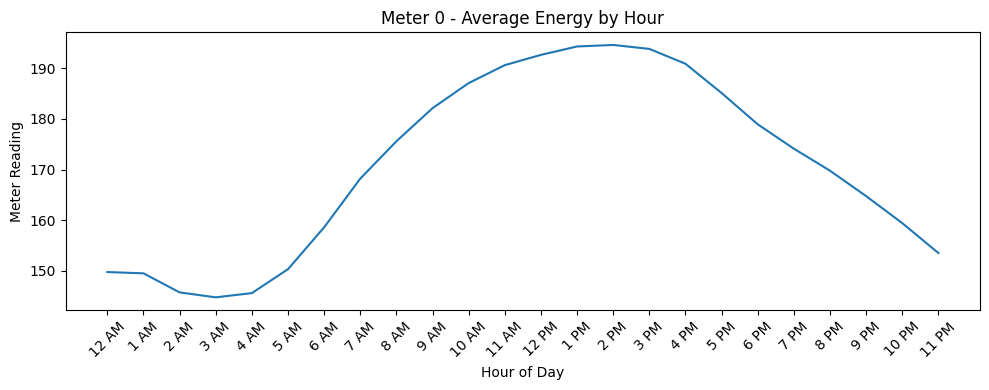

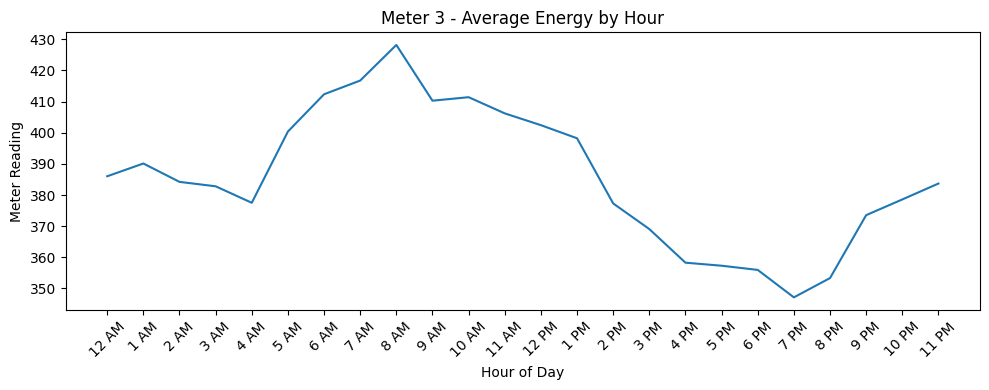

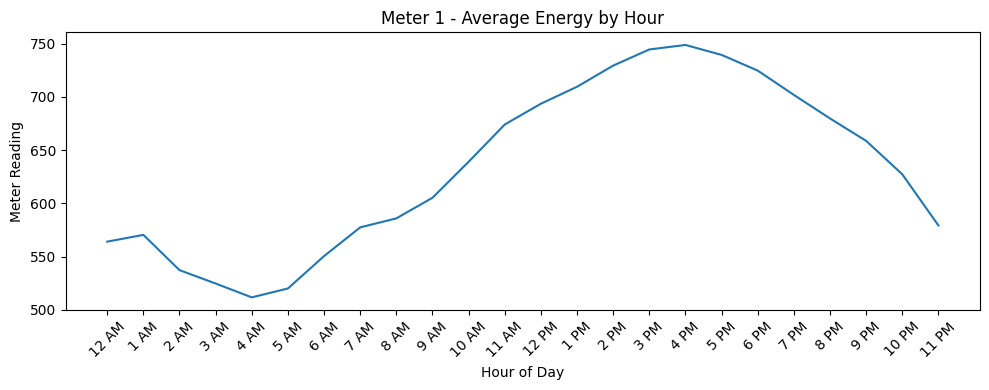

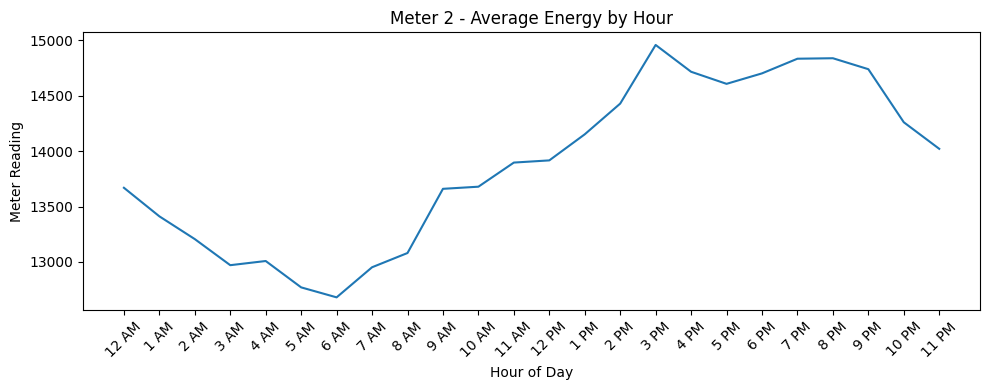

In [27]:
# ===============================
# 4. AVERAGE ENERGY BY HOUR (per meter type)
# ===============================

for m in df["meter"].unique():
    subset = df[df["meter"] == m]
    hourly = subset.groupby("hour")["meter_reading"].mean()

    plt.figure(figsize=(10,4))
    sns.lineplot(x=hourly.index, y=hourly.values)

    # ✅ Set all 24 hours with AM/PM labels
    plt.xticks(
        ticks=range(24),
        labels=[
            "12 AM","1 AM","2 AM","3 AM","4 AM","5 AM",
            "6 AM","7 AM","8 AM","9 AM","10 AM","11 AM",
            "12 PM","1 PM","2 PM","3 PM","4 PM","5 PM",
            "6 PM","7 PM","8 PM","9 PM","10 PM","11 PM"
        ],
        rotation=45
    )

    plt.title(f"Meter {m} - Average Energy by Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Meter Reading")

    plt.tight_layout()  # prevents overlap
    plt.show()

Observation:

Energy consumption is generally higher during daytime hours and lower during late night and early morning hours. 
This indicates that building activity significantly influences energy usage patterns.

### Monthly Energy Consumption

This plot illustrates how energy usage changes across different months of the year for each meter type. 
It helps in identifying seasonal trends in energy consumption.

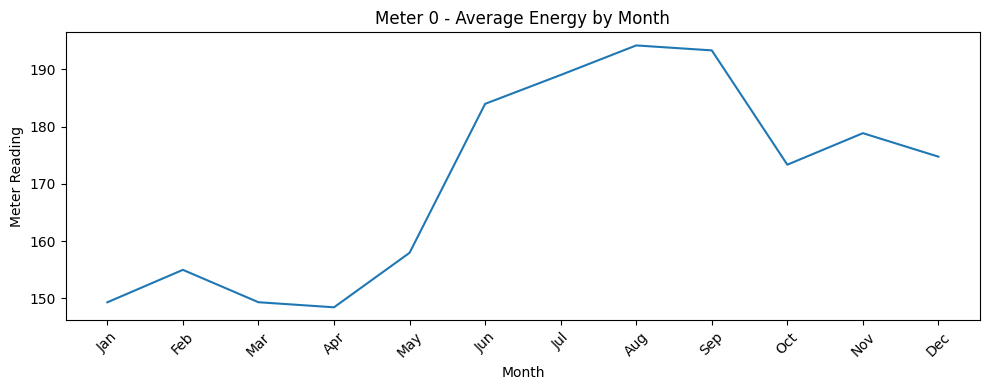

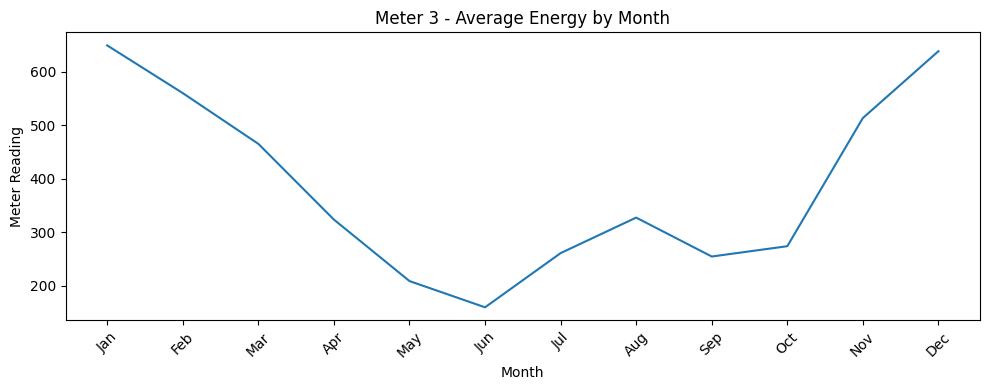

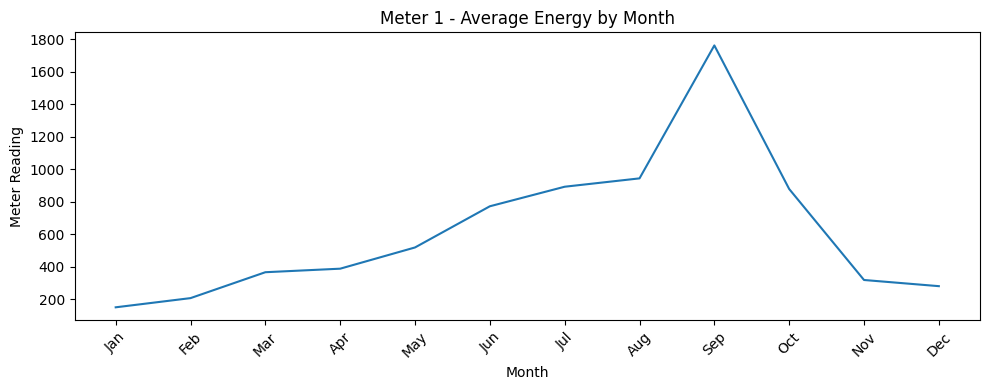

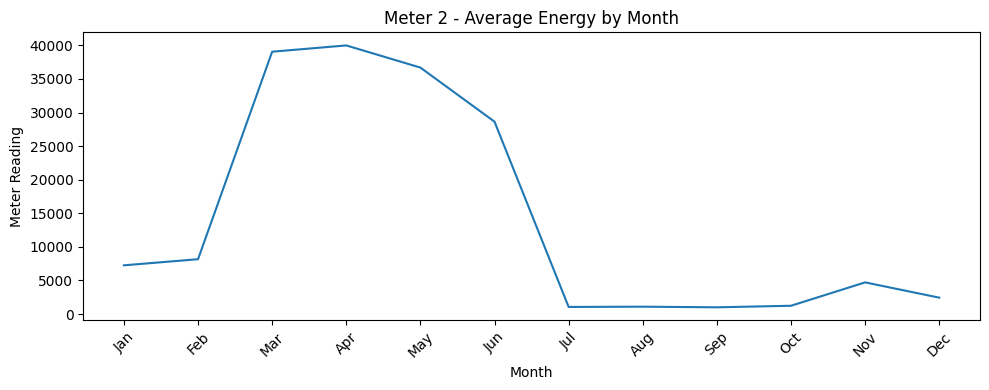

In [28]:
# ===============================
# 5. AVERAGE ENERGY BY MONTH (per meter type)
# ===============================

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

for m in df["meter"].unique():
    subset = df[df["meter"] == m]
    monthly = subset.groupby("month")["meter_reading"].mean()

    plt.figure(figsize=(10,4))
    sns.lineplot(x=monthly.index, y=monthly.values)

    # ✅ Set month names
    plt.xticks(ticks=range(1,13), labels=month_labels, rotation=45)

    plt.title(f"Meter {m} - Average Energy by Month")
    plt.xlabel("Month")
    plt.ylabel("Meter Reading")

    plt.tight_layout()
    plt.show()

Observation:

Energy usage varies across months, indicating seasonal trends. 
Higher consumption in certain months may be due to increased heating or cooling demands depending on weather conditions.

### Weekday vs Weekend Energy Usage

This plot compares the average energy consumption between weekdays and weekends. 
It helps in understanding how operational patterns affect energy usage.

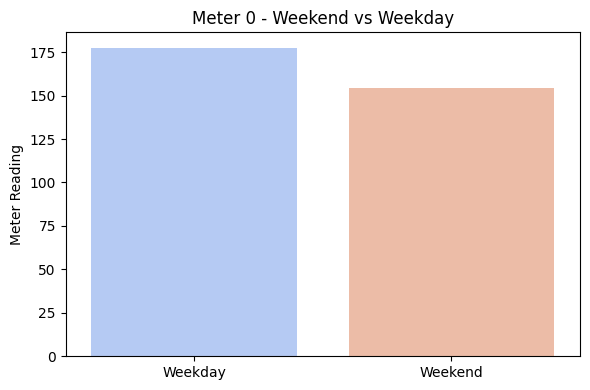

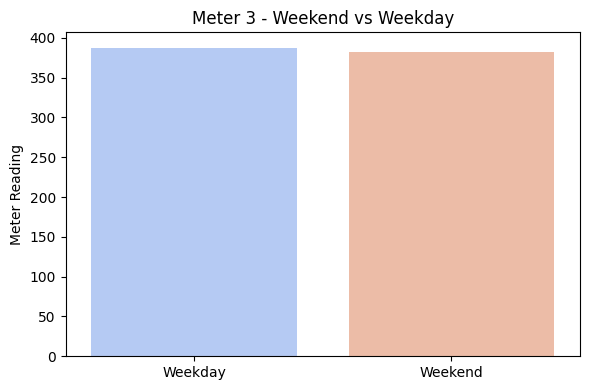

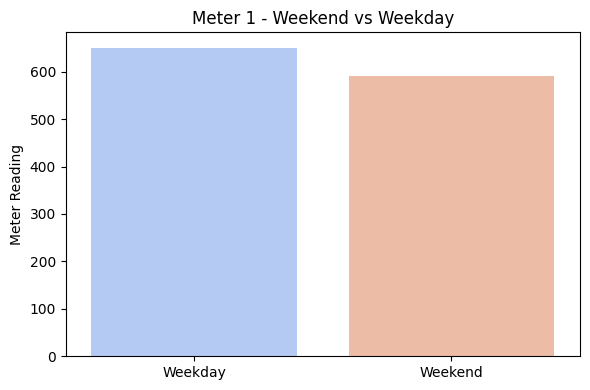

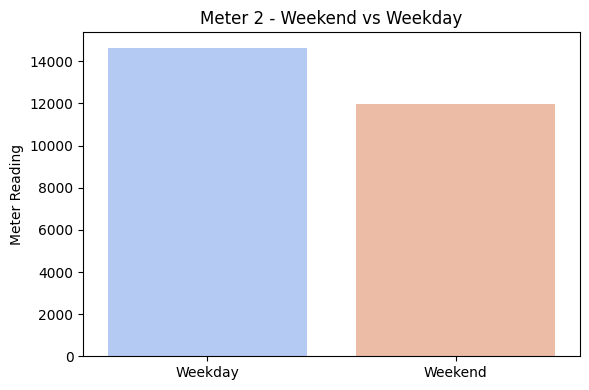

In [30]:
# ===============================
# 6. WEEKDAY vs WEEKEND
# ===============================

for m in df["meter"].unique():
    subset = df[df["meter"] == m]

    week = subset.groupby("is_weekend")["meter_reading"].mean().reset_index()

    plt.figure(figsize=(6,4))
    sns.barplot(
        data=week,
        x="is_weekend",
        y="meter_reading",
        hue="is_weekend",      
        palette="coolwarm",
        legend=False           
    )

    plt.xticks([0,1], ["Weekday", "Weekend"])

    plt.title(f"Meter {m} - Weekend vs Weekday")
    plt.xlabel("")
    plt.ylabel("Meter Reading")

    plt.tight_layout()
    plt.show()

Observation:

Energy consumption is generally higher on weekdays compared to weekends. 
This suggests that buildings are more actively used during working days, leading to increased energy demand.

### Energy Consumption Timeline for Selected Buildings

This plot shows the energy usage trend over time for three selected buildings across the year 2016. 
It helps in understanding how energy consumption varies over time at the building level.

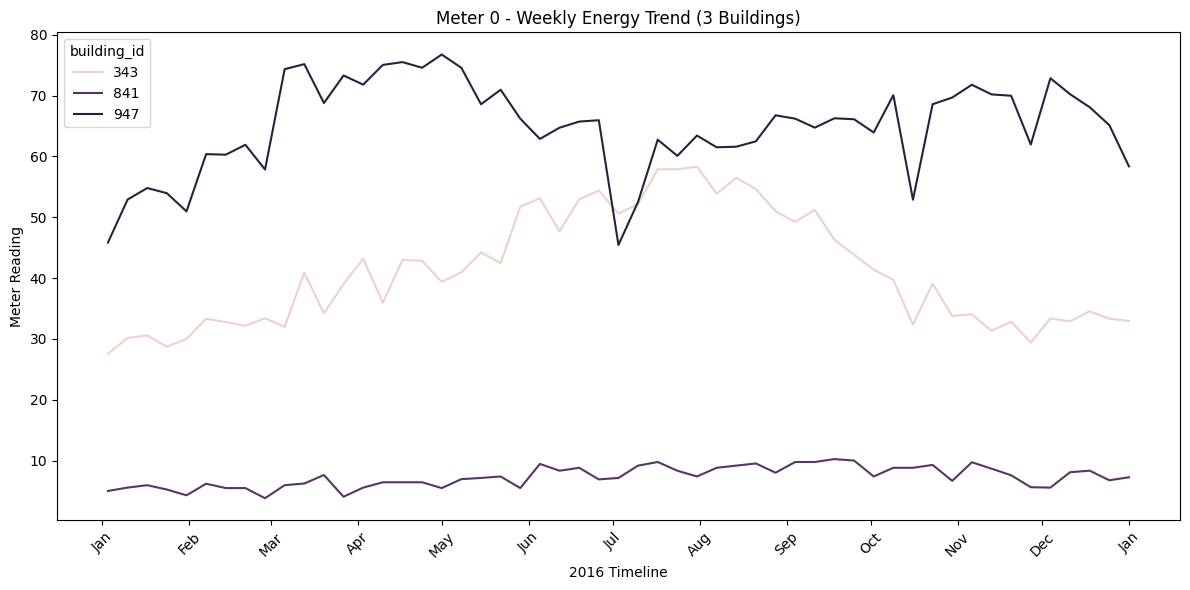

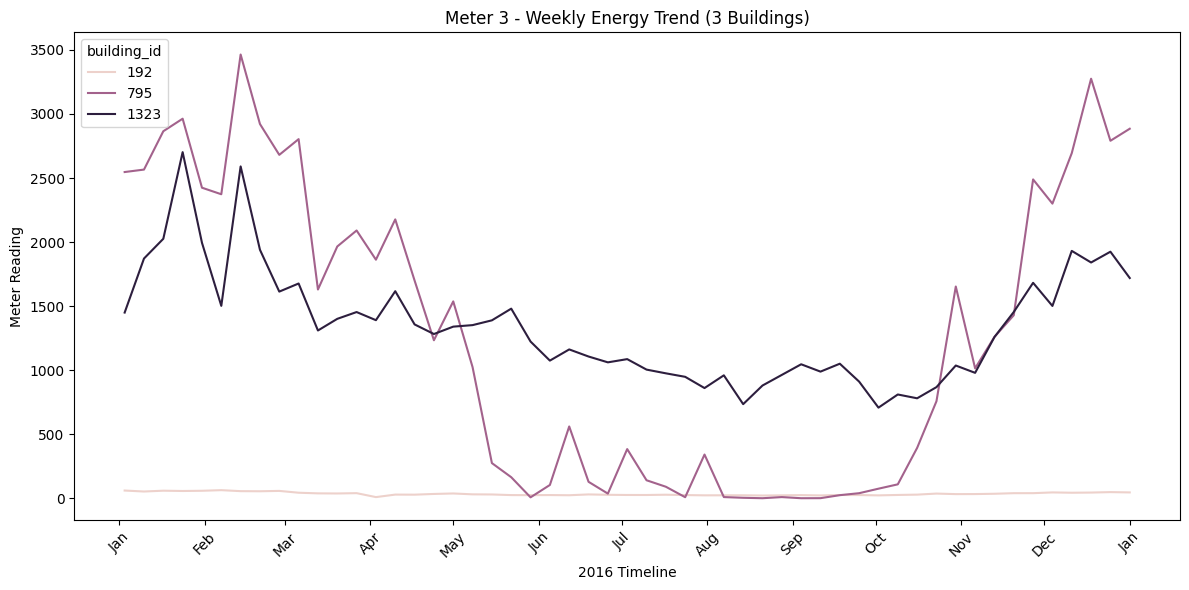

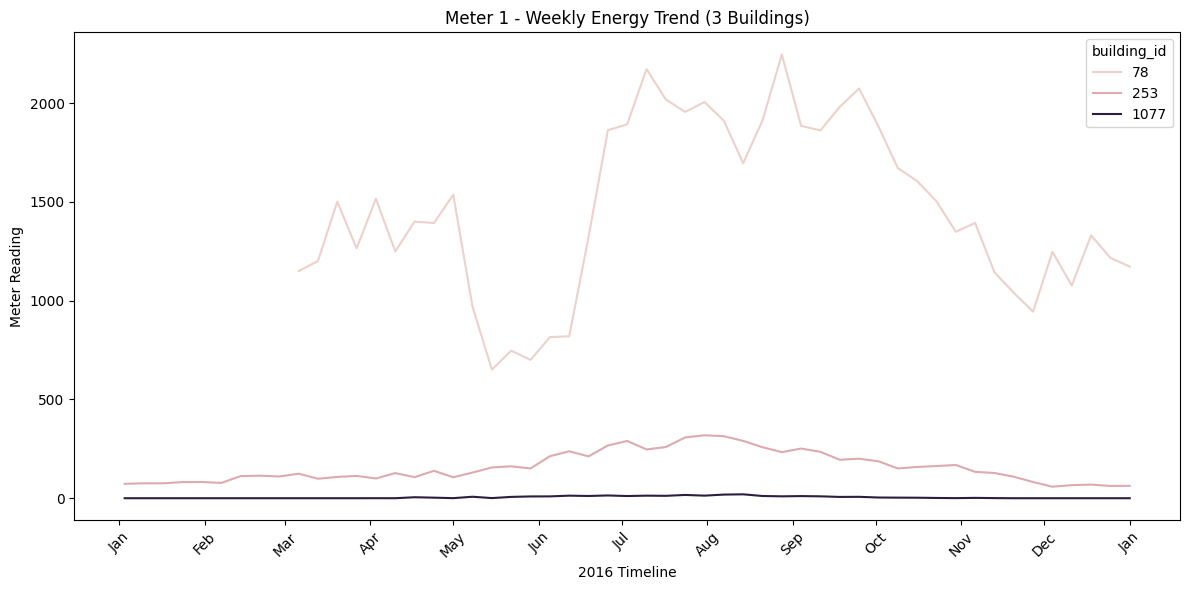

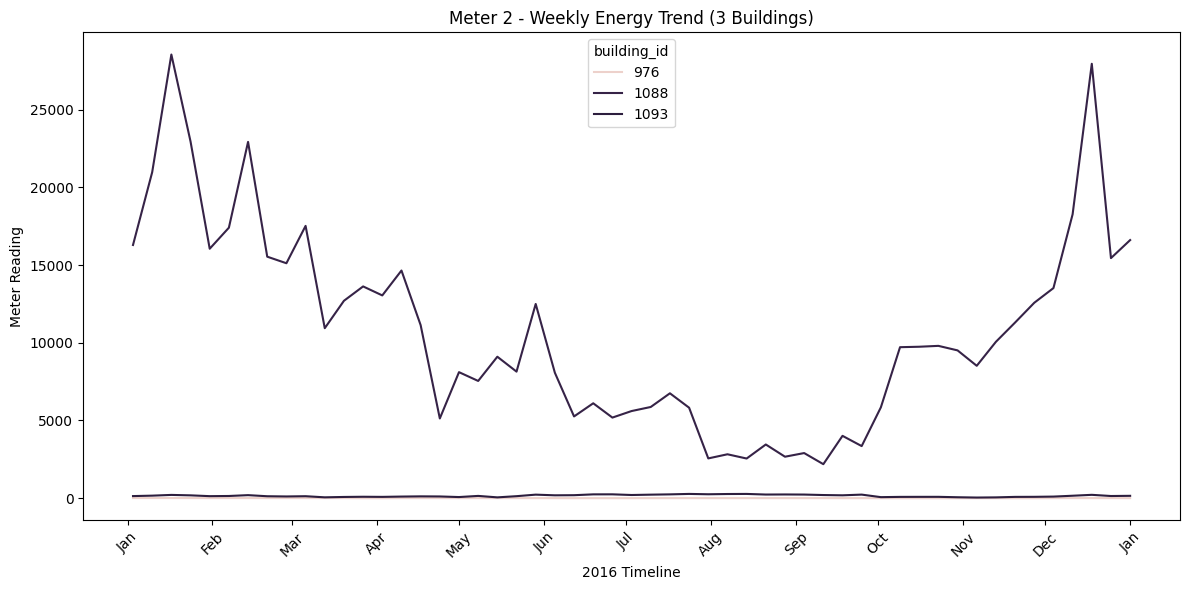

In [33]:
# ===============================
# 7. 3 BUILDINGS TIMELINE (2016)
# ===============================
import matplotlib.dates as mdates

for m in df["meter"].unique():
    subset = df[df["meter"] == m]

    if len(subset) == 0:
        continue

    # pick 3 buildings
    sample_buildings = subset["building_id"].drop_duplicates().sample(3, random_state=42)
    subset_3 = subset[subset["building_id"].isin(sample_buildings)]

    # convert timestamp to weekly average
    subset_3 = subset_3.set_index("timestamp")
    # filter only 2016
    subset_3 = subset_3[
    (subset_3.index >= "2016-01-01") & 
    (subset_3.index < "2017-01-01")
]
    weekly = subset_3.groupby(["building_id"]).resample("W")["meter_reading"].mean().reset_index()

    plt.figure(figsize=(12,6))
    sns.lineplot(data=weekly, x="timestamp", y="meter_reading", hue="building_id")

    # ✅ FORMAT X-AXIS TO MONTH NAMES
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # every month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Jan, Feb, Mar

    plt.title(f"Meter {m} - Weekly Energy Trend (3 Buildings)")
    plt.xlabel("2016 Timeline")
    plt.ylabel("Meter Reading")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Observation:

The energy usage shows fluctuations over time, with some consistent patterns visible across buildings. 
Due to high-frequency variations in the data, the overall trend is more important than individual spikes. 
This indicates that energy consumption follows recurring patterns with some variability across buildings.

### Heatmap of Energy Usage (Month vs Hour)

This heatmap represents the average energy consumption across different months and hours of the day. 
It provides a combined view of both daily and seasonal patterns in energy usage.

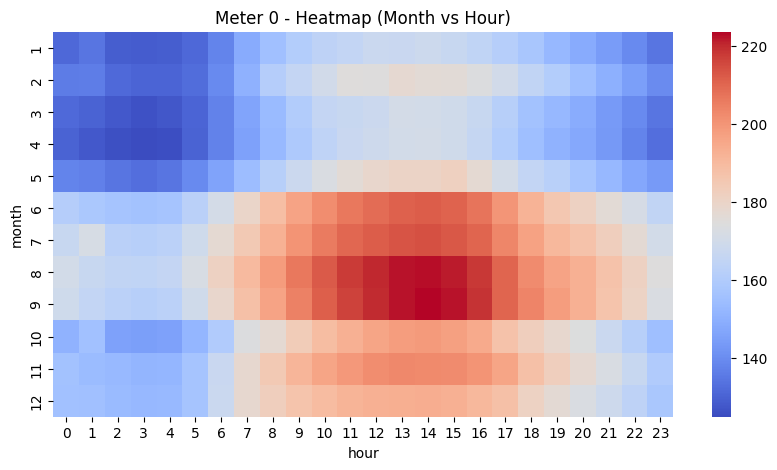

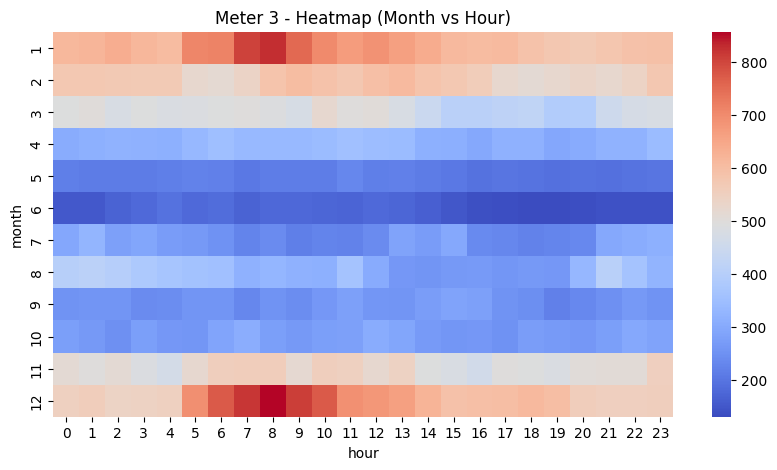

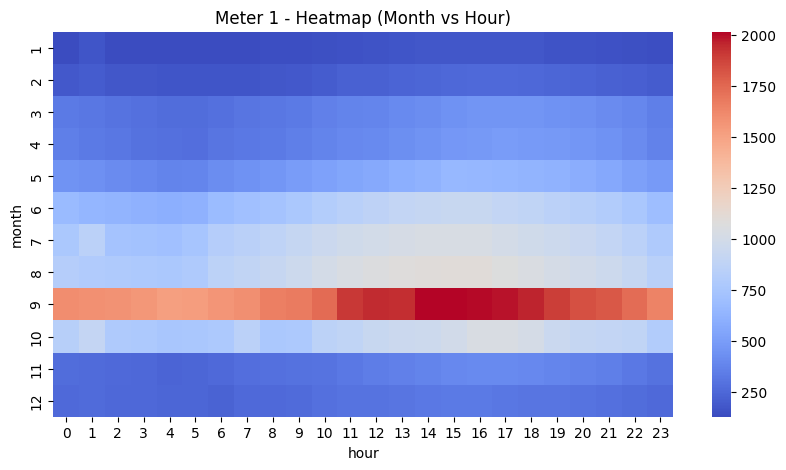

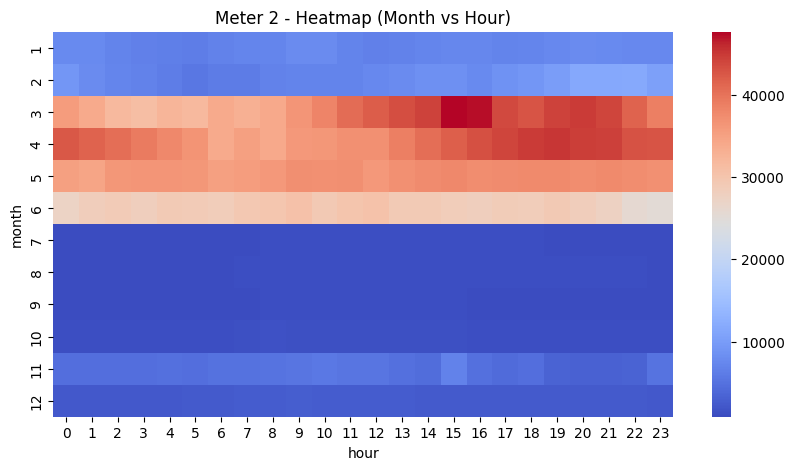

In [19]:
# ===============================
# 8. HEATMAP (Month vs Hour)
# ===============================
for m in df["meter"].unique():
    subset = df[df["meter"] == m]

    heatmap_data = subset.pivot_table(
        values="meter_reading",
        index="month",
        columns="hour",
        aggfunc="mean"
    )

    plt.figure(figsize=(10,5))
    sns.heatmap(heatmap_data, cmap="coolwarm")
    plt.title(f"Meter {m} - Heatmap (Month vs Hour)")
    plt.show()

Observation:

The heatmap shows that energy usage depends on both time of day and month. 
Certain hours and months exhibit higher consumption, indicating peak usage periods. 
This combined effect highlights the importance of temporal features in understanding energy patterns.

In [12]:
# ===============================
# 9. SUMMARY STATISTICS (OPTIONAL BUT GOOD)
# ===============================
print("\nSummary Statistics:")
print(df["meter_reading"].describe())


Summary Statistics:
count    2.021610e+07
mean     2.117121e+03
std      1.532356e+05
min      0.000000e+00
25%      1.830000e+01
50%      7.877500e+01
75%      2.679840e+02
max      2.190470e+07
Name: meter_reading, dtype: float64


Key Findings:

• Time-based features (hour, day_of_week, month) were successfully extracted from the timestamp for temporal analysis

• Hourly analysis shows that peak energy usage occurs during afternoon hours (approximately 12 PM – 4 PM), while lowest usage is observed during early morning hours (12 AM – 5 AM)

• Monthly trends show clear seasonal variation:
  o Meter 0 peaks around July–September (~180–190) and is lowest in January–March (~145–155)
  o Meter 1 shows highest usage around September (~1700–1800) and lowest in January (~150–200)
  o Meter 2 has extremely high values in March–May (~38,000–40,000) and drops significantly after June
  o Meter 3 shows higher usage at the beginning and end of the year (~600–650) and lowest around mid-year (~150–250)

• Weekday vs weekend comparison shows consistently higher energy usage on weekdays across all meters:
  o Meter 0: ~175 (weekday) vs ~155 (weekend)
  o Meter 1: ~650 vs ~600
  o Meter 2: ~14,500 vs ~12,000
  o Meter 3: ~390 vs ~380

• Weekly trend analysis (smoothed timeline) shows consistent seasonal patterns across buildings, with gradual increases and decreases rather than random noise

• Heatmap analysis (month vs hour) highlights that peak energy usage occurs during afternoon hours (12–4 PM) and specific months depending on meter type

• Significant variation exists between meter types, with Meter 2 having much higher values compared to others, so separate visualizations were used for clarity

• Overall, energy consumption is strongly influenced by temporal features such as hour, day, and month, making them important for further modelling

---

## Sprint 2 — Time Series Patterns & Feature Analysis

---

## Sprint 3 — LightGBM Model Development & Tuning

---

## Sprint 4 — Evaluation & Report